In [2]:
import pystac

# STAC URL
url = "https://capella-open-data.s3.us-west-2.amazonaws.com/stac/capella-open-data-ieee-data-contest/collection.json"

print("Loading STAC collection...")
collection = pystac.Collection.from_file(url)
print("Collection loaded ✅")

# Counters
count = 0
geo_count = 0
slc_count = 0
other_count = 0

print("\nFetching items and counting types...")

for item in collection.get_items():
    count += 1

    # Count types
    if "GEO" in item.id:
        geo_count += 1
    elif "SLC" in item.id:
        slc_count += 1
    else:
        other_count += 1

    # Progress update
    if count % 100 == 0:
        print(f"Processed {count} items...")

# Final results
print("\nDataset Summary ✅")
print(f"Total SAR images: {count}")
print(f"GEO images: {geo_count}")
print(f"SLC images: {slc_count}")
print(f"Other types: {other_count}")

Loading STAC collection...
Collection loaded ✅

Fetching items and counting types...
Processed 100 items...
Processed 200 items...
Processed 300 items...
Processed 400 items...
Processed 500 items...
Processed 600 items...
Processed 700 items...
Processed 800 items...
Processed 900 items...
Processed 1000 items...
Processed 1100 items...
Processed 1200 items...
Processed 1300 items...
Processed 1400 items...
Processed 1500 items...

Dataset Summary ✅
Total SAR images: 1582
GEO images: 791
SLC images: 791
Other types: 0


In [4]:
import pystac

url = "https://capella-open-data.s3.us-west-2.amazonaws.com/stac/capella-open-data-ieee-data-contest/collection.json"

print("Loading STAC collection...")
collection = pystac.Collection.from_file(url)
print("Collection loaded ✅")

# Counters
count = 0
geo_count = 0
slc_count = 0
other_count = 0

limit = 10   # 👈 only process 10 images

print("\nFetching items and counting types (LIMITED)...")

for item in collection.get_items():
    count += 1

    if "GEO" in item.id:
        geo_count += 1
    elif "SLC" in item.id:
        slc_count += 1
    else:
        other_count += 1

    if count >= limit:   # 👈 stop after 10
        break

print("\nTest Summary (10 images) ✅")
print(f"Total checked: {count}")
print(f"GEO images: {geo_count}")
print(f"SLC images: {slc_count}")
print(f"Other types: {other_count}")

Loading STAC collection...
Collection loaded ✅

Fetching items and counting types (LIMITED)...

Test Summary (10 images) ✅
Total checked: 10
GEO images: 5
SLC images: 5
Other types: 0


In [9]:
ref_item = next(collection.get_items())

print(ref_item.geometry)

{'type': 'Polygon', 'coordinates': [[[-155.2601121, 19.37629504], [-155.33918783, 19.42715568], [-155.31223809, 19.46485619], [-155.23314965, 19.41398789], [-155.2601121, 19.37629504]]]}


In [10]:
import numpy as np

coords = ref_item.geometry['coordinates'][0]  # first polygon

lons = [pt[0] for pt in coords]
lats = [pt[1] for pt in coords]

ref_lon = np.mean(lons)
ref_lat = np.mean(lats)

print("Reference Center:", ref_lat, ref_lon)

Reference Center: 19.411717967999998 -155.280959954


In [11]:
same_location = []

for item in collection.get_items():
    try:
        coords = item.geometry['coordinates'][0]
        
        lons = [pt[0] for pt in coords]
        lats = [pt[1] for pt in coords]
        
        lon = np.mean(lons)
        lat = np.mean(lats)
        
        # threshold for same area
        if abs(lat - ref_lat) < 0.01 and abs(lon - ref_lon) < 0.01:
            same_location.append(item)
        
        if len(same_location) == 10:
            break
            
    except:
        continue

print("Collected:", len(same_location))

Collected: 10


In [12]:
for item in same_location:
    print(item.properties.get('datetime'))

2025-11-12T02:24:47.676882Z
2025-11-12T02:24:47.676937Z
2025-11-09T03:28:02.304377Z
2025-11-09T03:28:02.304321Z
2025-11-06T04:31:19.292211Z
2025-11-06T04:31:19.292155Z
2025-11-03T05:34:36.248627Z
2025-11-03T05:34:36.248631Z
2025-10-31T06:37:51.703680Z
2025-10-31T06:37:51.703736Z


In [13]:
unique_items = {}
from datetime import datetime

for item in same_location:
    dt = item.properties.get('datetime')
    
    # Extract only date (ignore time)
    date = dt[:10]  # 'YYYY-MM-DD'
    
    if date not in unique_items:
        unique_items[date] = item

# Convert to list
temporal_stack = list(unique_items.values())

print("Final stack size:", len(temporal_stack))

# Print dates
for item in temporal_stack:
    print(item.properties.get('datetime'))

Final stack size: 5
2025-11-12T02:24:47.676882Z
2025-11-09T03:28:02.304377Z
2025-11-06T04:31:19.292211Z
2025-11-03T05:34:36.248627Z
2025-10-31T06:37:51.703680Z


In [14]:
temporal_stack = sorted(
    temporal_stack,
    key=lambda x: x.properties.get('datetime')
)

In [15]:
import os
import rasterio
import numpy as np

os.environ["AWS_NO_SIGN_REQUEST"] = "YES"

images = []

for item in temporal_stack:
    url = item.assets['preview'].href
    
    with rasterio.open(url) as src:
        img = src.read(1, out_shape=(1, 256, 256))
    
    images.append(img)

images = np.array(images)

print("Final shape:", images.shape)

Final shape: (5, 256, 256)


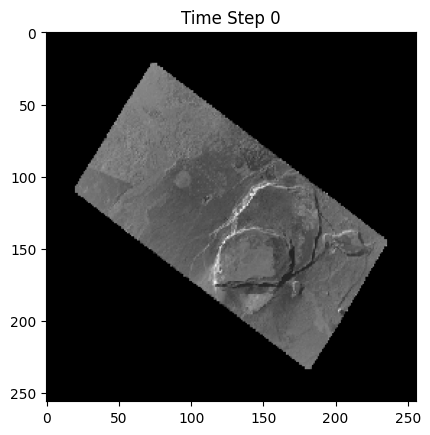

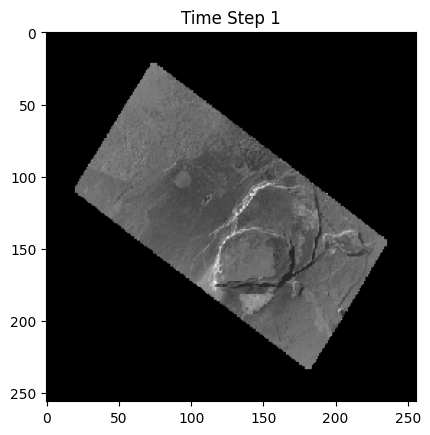

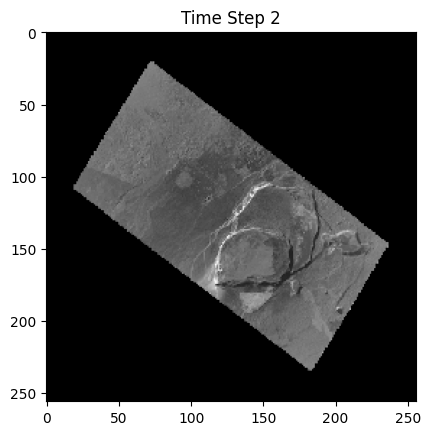

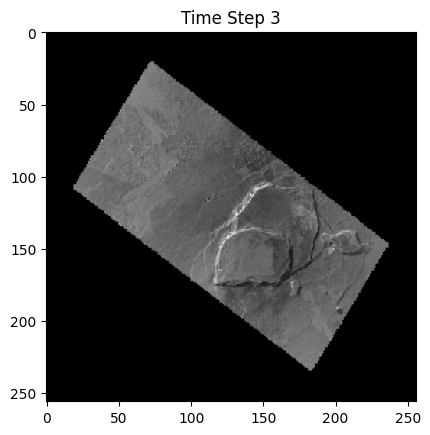

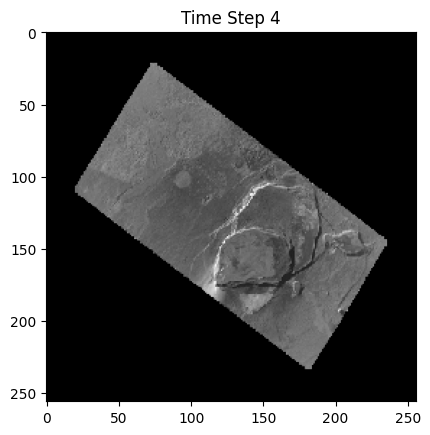

In [16]:
import matplotlib.pyplot as plt

for i in range(len(images)):
    plt.imshow(images[i], cmap='gray')
    plt.title(f"Time Step {i}")
    plt.show()

In [17]:
#✔ Same location
#✔ Different time
#✔ No duplicates
#✔ Ready for analysis

In [18]:
with rasterio.open(item.assets['preview'].href) as src:
    print("Original Width:", src.width)
    print("Original Height:", src.height)

Original Width: 51171
Original Height: 46671


In [19]:
images = images.astype('float32')

In [20]:
import numpy as np

images_log = np.log1p(np.abs(images))

In [21]:
mean = np.mean(images_log)
std = np.std(images_log)

images_norm = (images_log - mean) / std

In [22]:
images_norm = images_norm[..., np.newaxis]

print(images_norm.shape)

(5, 256, 256, 1)


In [27]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [28]:
import numpy as np

# images_norm shape: (T, 256, 256, 1)

images_torch = torch.tensor(images_norm, dtype=torch.float32)

# Convert to (T, C, H, W)
images_torch = images_torch.permute(0, 3, 1, 2)

# Move to GPU
images_torch = images_torch.to(device)

print(images_torch.shape)

torch.Size([5, 1, 256, 256])


In [29]:
import torch.nn as nn

class CNNEncoder(nn.Module):
    def __init__(self):
        super(CNNEncoder, self).__init__()
        
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(64 * 32 * 32, 64)  # feature vector

    def forward(self, x):
        x = self.encoder(x)
        x = self.flatten(x)
        x = self.fc(x)
        return x

In [30]:
model = CNNEncoder().to(device)
model.eval()

CNNEncoder(
  (encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc): Linear(in_features=65536, out_features=64, bias=True)
)

In [31]:
with torch.no_grad():
    features = model(images_torch)

features = features.cpu().numpy()

print("Feature shape:", features.shape)

Feature shape: (5, 64)


In [32]:
import numpy as np

feature_changes = []

for i in range(len(features)-1):
    diff = np.linalg.norm(features[i] - features[i+1])
    feature_changes.append(diff)

print("Feature changes:", feature_changes)

Feature changes: [0.009686902, 0.043057334, 0.01405853, 0.041637644]


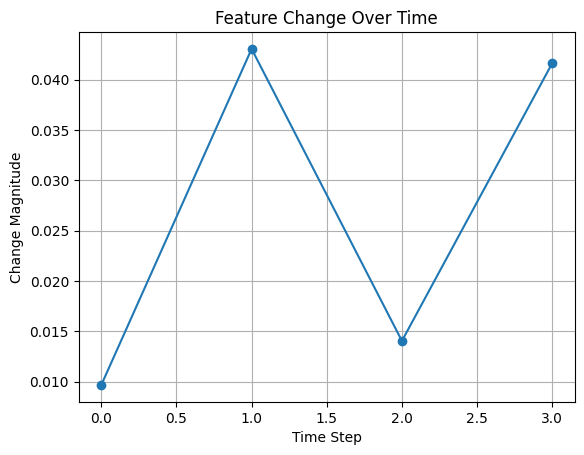

In [33]:
import matplotlib.pyplot as plt

plt.plot(feature_changes, marker='o')
plt.title("Feature Change Over Time")
plt.xlabel("Time Step")
plt.ylabel("Change Magnitude")
plt.grid()
plt.show()

In [34]:
from sklearn.metrics.pairwise import cosine_similarity

sim_matrix = cosine_similarity(features)

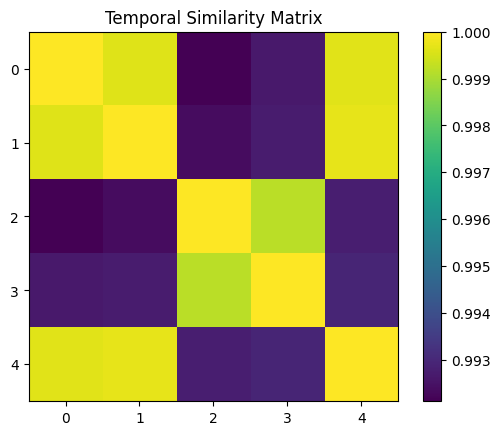

In [35]:
plt.imshow(sim_matrix, cmap='viridis')
plt.colorbar()
plt.title("Temporal Similarity Matrix")
plt.show()

In [36]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
features_2d = pca.fit_transform(features)

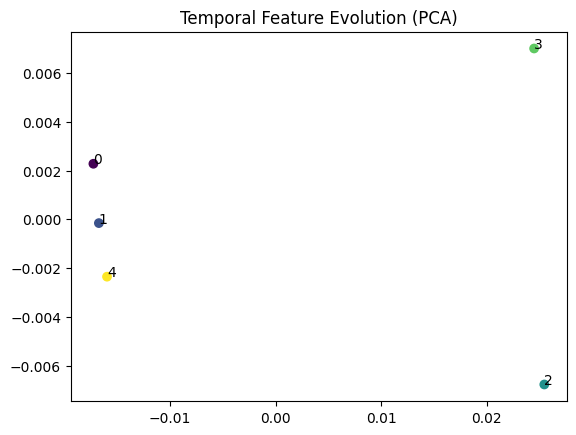

In [37]:
plt.scatter(features_2d[:,0], features_2d[:,1], c=range(len(features)))
for i in range(len(features)):
    plt.text(features_2d[i,0], features_2d[i,1], str(i))

plt.title("Temporal Feature Evolution (PCA)")
plt.show()